In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [3]:
# Laod Dataset
data = fetch_california_housing()
# use only median income for simplicity
X, y = data.data[:, [0]], data.target

In [4]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
# underfitting : Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_train_pred_lin = lin_reg.predict(X_train)
y_test_pred_lin = lin_reg.predict(X_test)

In [11]:
print("Linear Regression Train MSE :", mean_squared_error(y_train, y_train_pred_lin))
print("Linear Regression Test MSE :", mean_squared_error(y_test, y_test_pred_lin))

Linear Regression Train MSE : 0.7051366781970437
Linear Regression Test MSE : 0.6917979868048499


In [12]:
# OverFitting: Polynomial Regression
poly_reg = make_pipeline(PolynomialFeatures(15), LinearRegression())
poly_reg.fit(X_train, y_train)
y_train_pred_poly = poly_reg.predict(X_train)
y_test_pred_poly = poly_reg.predict(X_test)

In [13]:
print("Polynomial Regression Train MSE :", mean_squared_error(y_train, y_train_pred_poly))
print("Polynomial Regression Test MSE :", mean_squared_error(y_test, y_test_pred_poly))

Polynomial Regression Train MSE : 0.8096448526167815
Polynomial Regression Test MSE : 0.8139059529364612


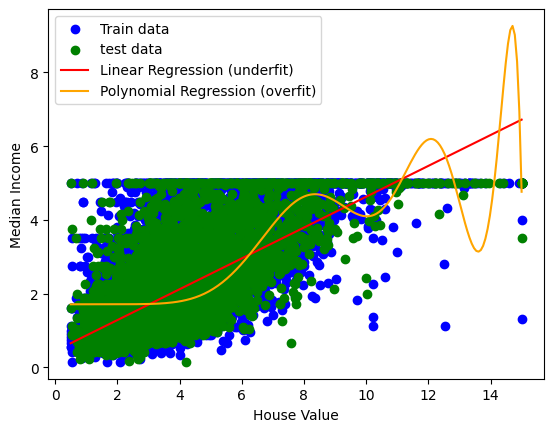

In [15]:
# ----- visualization --------------

plt.scatter(X_train, y_train, color="blue", label="Train data")
plt.scatter(X_test, y_test, color="green", label="test data")

X_range = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
plt.plot(X_range, lin_reg.predict(X_range), color="red", label="Linear Regression (underfit)")
plt.plot(X_range, poly_reg.predict(X_range), color="orange", label = "Polynomial Regression (overfit)")

plt.legend()
plt.ylabel("Median Income")
plt.xlabel('House Value')
plt.show()